## Meta 2

Nesta segunda meta, temos como principal objetivo explorar e tratar a extração de features, assim como utilizar features embebidas obtidas através dos dados. Deste modo, pretendemos estabelecer um modelo de análise de dados que nos possa permitir reconhecer e identificar as atividades em questão com base no tratamento de dados que realizamos. Nesta meta, foi possível aprender e aprofundar conhecimentos em diferentes algoritmos e técnicas, como o SMOTE, data splitting e as suas diferentes estratégias, classificadores de k-Nearest Neighbors, várias métricas de classificação e avaliação de performance, hyperparameter tuning para avaliar os melhores parâmetros a utilizar no nosso modelo e testes para avaliar qual é o melhor modelo dentro daqueles que obtivemos (como foi o caso de hypothesis testing).

Começamos por estabelecer todos os imports necessários para esta meta 2. É possível que existam imports sobrepostos com os anteriores da Meta 1, já que optámos por fazer o desenvolvimento desta segunda meta em source files distintos e, posteriormente, juntar tudo.

In [59]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import re
import random
import torch
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
import pickle
import re

from ReliefF import ReliefF

import pandas as pd

from scipy.stats import wilcoxon

In [60]:
def loadData(deviceId):
    """Carrega dados de todos os ficheiros CSV com tratamento de erros"""
    base_dir = '../dataset'
    dataset = {}
    
    if deviceId == None:
        for i in range(0, 15):
            folder = os.path.join(base_dir, f"part{i}")
            for j in range(1, 6):
                file = f"part{i}dev{j}.csv"
                path = os.path.join(folder, file)
                data = np.loadtxt(path, delimiter=',')
                if data is None:
                    continue

                dataset[f"part{i}dev{j}"] = data

    else:
        for i in range(0, 15):
            folder = os.path.join(base_dir, f"part{i}")
            file = f"part{i}dev{deviceId}.csv"
            path = os.path.join(folder, file)
            data = np.loadtxt(path, delimiter=',')

            if data is None:
                continue

            dataset[f"part{i}dev{deviceId}"] = data

    return dataset

### Exercício 1.1. Analyse the balance between the number of examples available for the set of activities you are considering. Is the dataset balanced?

Neste exercício, temos como objetivo analisar o dataset como um todo, comparando o número de samples existentes no dataset de acordo com o número de atividades. Tal como foi solicitado no início desta Meta 2, nós excluímos as atividades superiores ao índice 7 e a análise foi executada apenas às atividades de 1 a 7. Os resultados desta análise serão analisados mais à frente, em conjunto com as restantes alíneas do exercício 1.

In [61]:
def analyze_data(data):

    """Analisar o equilibrio entre os dados"""
    """Vamos ver quantas amostras temos de cada atividade"""

    """Vamos aproveitar para excluir atividades com label > 7 do dataset"""
    activity_counts = {}
    for key, values in data.items():

        filtered_rows = values[values[:, 11] <= 7]
        data[key] = filtered_rows
        for row in filtered_rows:
            activity = int(row[11]) #buscar cada label de atividade
            if activity > 7:
                continue
            if activity in activity_counts:
                activity_counts[activity] += 1
            else:
                activity_counts[activity] = 1

    return activity_counts

### Exercício 1.2. Create  a  function  that  receives  the  dataset  and  implements  the  SMOTE  method  to generate K new samples for a given activity A. 

O exercício 1.2. solicita a implementação do algoritmo/método SMOTE. O SMOTE (Synthetic Minority Oversampling Technique) é uma técnica de criação de dados sintéticos para classes/conjuntos minoritários num dataset. Esta técnica é importantíssima para resolver problemas em datasets desbalanceados, como é o caso do nosso, em que o objetivo final é obter um modelo devidamente treinado a reconhecer atividades não "labeladas".

Ora, se hipoteticamente estivermos a trabalhar com 900 samples de uma classe 1 e 100 samples de uma classe 2, o modelo vai ter um treino muito mais exaustivo a reconhecer a classe 1 do que a classe 2. Além disso, terá sempre uma chance de 90% de acertar "sem esforço" por escolher a classe 1, já que é uma classe maioritária.

Para combater isto, temos uma solução inteligente que é o SMOTE, que cria samples artificiais que são sempre ligeiramente diferentes das originais, mas continuam a ter as características da classe minoritária em questão. 

A aplicação do SMOTE baseia-se em geometria, em que escolhe um ponto/amostra da classe minoritária, procura os seus vizinhos (os pontos mais próximos dele que sejam da mesma classe minoritária) e cria um novo ponto num local aleatório na linha reta que conecta os dois pontos do dataset original. Ou seja, a sample artificial é obtida através de dois pontos originais.

In [ ]:
def smote_activity(dataset, activity_label, n_to_generate, k_neighbors = 5):
    """Aplicar o SMOTE a uma atividade específica do dataset"""

    activity_samples = []
    for key, values in dataset.items():
        for row in values:
            if int(row[11]) == activity_label:
                activity_samples.append(row)

    if len(activity_samples) == 0:
        print("Não foram encontradas samples para a atividade especificada, abortar SMOTE.")
        return np.empty((0, 12))

    # Concatenar todas as samples da atividade num único array
    activity_samples = np.vstack(activity_samples)

    # Separar características e labels
    X = activity_samples[:, :11] 
    N = X.shape[0]

    if N < 2:
        print("Número insuficiente de samples para aplicar SMOTE.")
        return np.empty((0, 12))
    
    # Vamos definir o número de vizinhos que devem ser considerados
    # É importante considerar que deve ser pelo menos 2

    K = min(k_neighbors, N - 1)

    neighbors = NearestNeighbors(n_neighbors=K + 1).fit(X)

    samples_sinteticas = []

    for _ in range(n_to_generate):
        
        # Vamos escolher uma amostra aleatória
        idx = random.randrange(N)
        random_sample = X[idx].reshape(1, -1)

        # Encontrar os K vizinhos mais próximos

        _, indices = neighbors.kneighbors(random_sample)

        neighbors_indices = indices[0][1:]

        # Vamos escolher um vizinho aleatório

        n_idx = random.choice(neighbors_indices)
        X_n = X[n_idx]

        # Vamos interpolar linearmente para criar uma nova amostra
        # A fórmula é X_new = X_idx + random(0,1) * (X_n - X_idx)

        diff = X_n - X[idx]
        gap = random.random()

        X_new = X[idx] + gap * diff

        sample_sintetica_com_label = np.append(X_new, activity_label)
        samples_sinteticas.append(sample_sintetica_com_label)
    
    return np.array(samples_sinteticas)

In [ ]:
def visualize_smote(dataset, synthetic_samples):
    """
    2D scatter plot dos dados originais e sintéticos.
    1: Aceleração X
    2: Aceleração Y
    11: Activity Label
    """
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
    highlighted_color_for_synthetic = 'orange'
    plt.figure(figsize=(10, 8))
    
    # Agrupar pontos originais por atividade (1..7)
    activity_sets = {a: [] for a in range(1, 8)}
    for key, values in dataset.items():
        for row in values:
            activity = int(row[11])
            if activity > 7:
                continue
            activity_sets[activity].append(row)

    # Plotar uma vez por atividade (Dados Originais)
    for activity, rows in activity_sets.items():
        if len(rows) == 0:
            continue
        arr = np.vstack(rows)

        plt.scatter(arr[:, 1], arr[:, 2], c=colors[activity - 1], marker='o', s=8, alpha=0.5, label=f'Atividade {activity}')

    # Plotar pontos sintéticos por atividade
    synth = np.array(synthetic_samples)
    
    # Verificar se existem samples sintéticas antes de tentar plotar
    if synth.ndim > 1 and synth.shape[0] > 0:
        for activity in range(1, 8):
            rows = synth[synth[:, 11] == activity]
            if rows.shape[0] == 0:
                continue
            
            plt.scatter(rows[:, 1], rows[:, 2], c=highlighted_color_for_synthetic, marker='x', s=50, linewidths=2, label=f'Sintética Atividade {activity}')

    plt.title('Visualização de Samples Originais e Sintéticas (Acelerometro X vs Acelerometro Y)')
    plt.xlabel('Eixo X do Acelerometro')
    plt.ylabel('Eixo Y do Acelerometro')
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

--- 1. CARREGAR DADOS ---
Features e Nomes carregados com sucesso.
{1: 805541, 2: 421504, 3: 418688, 4: 699414, 5: 703766, 6: 446411, 7: 223179}
Aplicando SMOTE...
Samples sintéticas geradas.


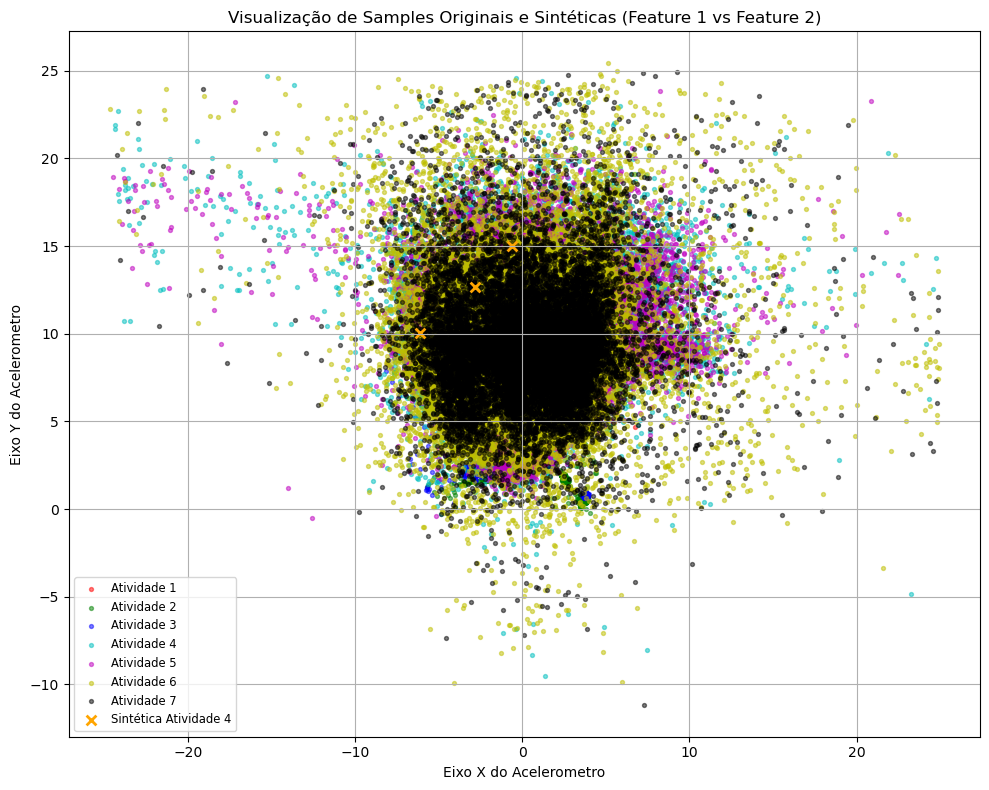

In [ ]:
activities_map = {
    1: 'STAND', 
    2: 'SIT', 
    3: 'SIT AND TALK', 
    4: 'WALK', 
    5: 'WALK AND TALK', 
    6: 'CLIMB STAIR (UP/DOWN)', 
    7: 'CLIMB STAIR (UP/DOWN) AND TALK'
}

# --- 1. CARREGAR DADOS ---
print("--- 1. CARREGAR DADOS ---")
features_dataset = None
with open('../features.pkl', 'rb') as f:
    data = pickle.load(f)

    if isinstance(data, dict):
        features_dataset = data['features']
        feature_names = data['names']
        print("Features e Nomes carregados com sucesso.")
    else:
        features_dataset = data
        # Não existe nomes, temos de gerar valores aleatórios
        # Gera nomes feat_0, feat_1... se não existirem
        feature_names = [f"feat_{i}" for i in range(features_dataset.shape[1])]

dataset = loadData(None)
activity_counts = analyze_data(dataset) 
print(activity_counts)
# Vamos aplicar o SMOTE para gerar e visualizar 3 novas samples
# da atividade 4, do participante 3
# Atenção, só devem ser utilizadas as samples do participante 3 para gerar as novas samples
atividade_alvo = 4
n_generate = 3

# Filtrar o dataset para incluir apenas samples do participante 3
dataset_participante3 = {}

# Como as keys estão no formato "partXdevY", podemos filtrar por "part3"
for key, values in dataset.items():
    if "part3" in key:
        dataset_participante3[key] = values

print("Aplicando SMOTE...")
samples_sinteticas = smote_activity(dataset_participante3, atividade_alvo, n_to_generate=n_generate)

print("Samples sintéticas geradas.")

visualize_smote(dataset_participante3, samples_sinteticas)

Nos resultados do exercício 1.1, foi nos revelado que o dataset se demonstra desbalanceado. Por exemplo, a classe 1 tem praticamente 4 vezes mais samples que a classe 7. Isto irá, mais à frente, refletir negativamente na funcionalidade do modelo na deteção da Atividade 7. Considerámos a aplicação do SMOTE para balancear o dataset como um todo mas, devido ao peso computacional (já que se fôssemos equilibrar as Atividades 1 e 7, teríamos de criar aproximadamente 600.000 samples para a atividade 7), optámos por não o fazer e utilizar o SMOTE em outra instância.

Queremos apenas estabelecer que, inicialmente, o dataset se revela desbalanceado e que a aplicabilidade do SMOTE ao mesmo poderia ser útil e provavelmente aumentaria a precisão e estabilidade do modelo, mas como obtivemos uma precisão considerada satisfatória, não o fizemos.

Com a aplicação de exemplo do SMOTE, no exercício 1.2, foram criadas 3 samples artificiais para a atividade 4. Como é possível ver no plot, temos as samples sintéticas bem destacadas no meio da "mancha" que está exibida. Optámos por incluir no plot todas as atividades, mas o foco é analisar as samples da atividade 4. Por coinciência, todas as atividades parecem, de certa forma, um pouco concentradas no meio do plot mas o caso da atividade 4 até se considera um tanto disperso, o que pode justificar o facto das samples artificiais em questão não estarem necessariamente no centro da mancha de dados.

## Exercício 2

Use only the x,y,z values of the accelerometer sensor. For each 5-second segment, resample it to 30Hz and then extract the embedding features (see provided code). You should  end  up  with  a  dataset  of  shape  [n_segments,  n_embeddings].  This  will  be referred to as “EMBEDDINGS DATASET”, while the one resulting from module A will be referred to as “FEATURES DATASET”.

In [65]:
#importar funções do embeddings_extractor.py
#============================================
def load_model():
  ''' Loads the model from the github repo and obtains just the feature encoder. '''

  repo = 'OxWearables/ssl-wearables'
  # class_num não interessa para extrair features; mas o hub pede este arg
  model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
  model.eval()

  # Passo crucial: ficar só com a parte auto-supervisionada
  # O README diz que há um 'feature_extractor' (pré-treinado) e um 'classifier' (não treinado). :contentReference[oaicite:14]{index=14}
  feature_encoder = model.feature_extractor
  feature_encoder.to("cpu")
  feature_encoder.eval()

  return feature_encoder

def acc_segmentation(data):
  ''' Estract ACC segments and their activities '''

  TIMESTAMP_COL = 10
  MIN_SEGMENT_SIZE = 20
  fs_in_hz = 51.5
  win_size = 5000
  start_time = data[0,TIMESTAMP_COL]
  end_time = start_time + win_size

  activities = []
  segments = []

  while end_time < data[-1,TIMESTAMP_COL]:
    mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

    if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

      acc_xyz = data[mask,1:4]
      activity = data[mask, -1][0]
      
      activities.append(activity)
      segments.append( acc_xyz )
      

    start_time = end_time - win_size/2
    end_time = start_time + win_size
  
  
  return segments, activities

def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
      acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
      fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target
#====================================

In [66]:
def embedding_features(dataset):
    feature_encoder = load_model()
    all_resampled_segments = [] #guardar todos os segmentos
    all_activities = [] #guardar todas as atividades
    all_subjects = []

    FS_IN_HZ = 51.5 #frequencia original (está no ficheiro embeddings_extractor.py)

    for key, data in dataset.items():

        match = re.search(r'part(\d+)', key)
        if match:
            subject_id = int(match.group(1))
        else:
            continue

        #segmentar os dados, apenas as colunas xyz do acc (o acc_segmentation ja faz isso)
        original_segments, activities = acc_segmentation(data)

        if not original_segments:
            continue    

        #reamostrar cada segmento para 30Hz e 5s
        for seg, act in zip(original_segments, activities):
            acc_resampled, fs_target = resample_to_30hz_5s(seg, FS_IN_HZ)
            all_resampled_segments.append(acc_resampled)
            all_activities.append(act)
            all_subjects.append(subject_id)
        
    #converter para array numpy
    x_all = np.array(all_resampled_segments)
    y_all = np.array(all_activities)
    s_all = np.array(all_subjects)

    print("[DEBUG]:", x_all.shape) #(N_SEGMENTOS (soma dos segmentos extraídos dos participantes), N_AMOSTRAS (5s x 30Hz), N_DIMENSOES (x,y,z pedidos do enunciado))
    print("[DEBUG]:", y_all.shape) #(N_SEGMENTOS,)

    #o modelo que vamos usar espera o input com shape [N_SEGMENTOS, N_DIMENSOES, N_AMOSTRAS], foi o que foi feito no embeddings_extractor.py
    x_all_transposed = np.transpose(x_all, (0, 2, 1)) 
    print("[DEBUG]:", x_all_transposed.shape) #(N_SEGMENTOS, N_DIMENSOES, N_AMOSTRAS)


    embeddings_list = []
    batch_size = 64

    with torch.no_grad():
        for i in range(0, x_all_transposed.shape[0], batch_size):
            xb = torch.from_numpy(x_all_transposed[i:i+batch_size]).float().to("cpu")
            eb = feature_encoder(xb) #shape = (batch_size, 64)
            embeddings_list.append(eb.cpu().numpy())
    
    embeddings_3d = np.concatenate(embeddings_list, axis=0)
    print("[DEBUG]:", embeddings_3d.shape) 

    #eles pedem para que o dataset final tenha o shape [N_SEGMENTS, N_EMBEDDINGS]
    embeddings_final = np.squeeze(embeddings_3d)
    print("[DEBUG]:", embeddings_final.shape) #(N_SEGMENTS, N_EMBEDD)

    y_all_reshaped = y_all.reshape(-1, 1) #(N_SEGMENTS, 1)
    s_all_reshaped = s_all.reshape(-1, 1) #(N_SEGMENTS, 1)

    EMBEDDINGS_DATASET = np.hstack((embeddings_final, y_all_reshaped, s_all_reshaped)) #(N_SEGMENTS, N_EMBEDDINGS + 1)
    print("[DEBUG]:", EMBEDDINGS_DATASET.shape)
    np.save('embeddings_dataset.npy', EMBEDDINGS_DATASET)

    return EMBEDDINGS_DATASET

In [67]:
if os.path.exists('embeddings_dataset.npy'):
        embedding_dataset = np.load('embeddings_dataset.npy')
else:
    embedding_dataset = embedding_features(dataset)

print(f"Shape original Features: {features_dataset.shape}")
print(f"Shape original Embeddings: {embedding_dataset.shape}")

Shape original Features: (27869, 148)
Shape original Embeddings: (29720, 514)


Neste exercício, o objetivo é extrair features automáticas usando transfer learning com o modelo HARNet5 pré-treinado, em vez de features manuais. 

Para a implementação, começamos por importar algumas funções auxiliares do "extract_features.py": load_model() que carrega o HARNet5 do repositório disponibilizado e que extrai apenas o encoder de features, acc_segmentation() que segmenta dados em janelas de 5 segundos (5000ms) com 50% overlap, filtrando apenas segmentos com atividade única, resample_to_30hz_5s() que reamostra os dados originais de ~51.5Hz para 30Hz usando interpolação linear.

De seguida, na nossa função principal embedding_features() começamos pela segmentação, extraindo janelas de 5s apenas do acelerómetro (x,y,z), como é pedido no enunciado. De seguida, fazemos o resampling, convertendo cada segmento para 30Hz (5s x 30Hz = 150 amostras). Fazemos uma transposição de (N,150,3) para (N,3,150) pois o input do modelo tem de ter esta configuração. Depois, fazemos uma extração, processamos em batches de 64 através do encoder => embeddings (N,512). Para o dataset final concatenamos os embeddings + labels + subject ID's.

No final, temos dois datasets para usar: um de features e um de embeddings. O de features possui 27869 segmentos e 148 colunas (146 features + 1 coluna de activity label + 1 coluna de subject ID). O de embeddings possui 29720 segmentos e 514 colunas (512 features aprendidas + 1 coluna de activity label + 1 coluna de Subject ID). O número de segmentos difere (27869 vs 29720) porque as features manuais usam todos os sensores (acc + gyro + mag) e o embeddings só usam apenas o acelerómetro (x,y,z). Além disso, diferentes janelas/overlap podem gerar constagens distintas.

### Exercício 3.    Data splitting strategy: We will use the same splitting strategies at two levels – within subject and between  subjects.  Split  both  the  FEATURES  and  the  EMBEDDINGS  datasets  into  training, validation, and test sets.

#### Exercício 3.1. Use a TVT split of 60-20-20% split, within each subject (data of a single subject is present in all sets) 

#### Exercício 3.2. Use the same split but at the subject level: put 9 subjects for training, 3 for validation, and 3 for testing.

#### Exercício 3.3. Discuss  the  differences  between  the  two  strategies.  Which  one  gives  you  a  better estimate of the performance of the model when applied to a new participant? Justify your answer.

#### Exercício 3.4. Prepare your pipeline in a way that, after the split, for each dataset, you can compute and transform each set into three different scenarios: 
####    a) All features/embeddings dataset 
####    b) PCA-reduced  features/embeddings  dataset  (keeping  just  the  components that explain   90% of the variance) 
####    c) Feature-selected  features/embeddings  (keeping  just  the  top  15  features selected by the ReliefF method). 
####    NOTE: Beware that you cannot use any test segment in the computations of the PCA or ReliefF in this question, as well as for any normalization procedure you follow. 

Para o exercício 3, definimos a estratégia de partição de dados e a pipeline de processamento que irá suportar o treino dos modelos nas etapas seguintes. Implementámos uma arquitetura que permite alternar entre estratégias de splits e métodos de redução de dimensionalidade (PCA/ReliefF) conformo o desejado.

De acordo com aquilo que foi solicitado, implementámos duas estratégias de divisão de dados distintas (60% para Treino, 20% para Validação e 20% para Teste). As diferenças entre estas duas estratégias podem ser resumidas pelo seu nível de abstração, sendo que uma é a nível das amostras e a outra é a nível dos participantes.

- **Random Split (Within-Subject):** 
    Nesta abordagem, a divisão dos dados é realizada por participante. Para cada um dos 15 participantes (Subjects), extraímos aleatoriamente 60% das suas amostras para treino, 20% para validação e 20% para teste. Posteriormente, todos os subconjuntos de todos os participantes são agregados.

    Esta abordagem tem uma tendência a produzir accuracies mais elevadas do que o próximo método, já que permite que o modelo tenha acesso a vários contextos e participantes diferentes durante o seu treino. Além disso, em vários casos, pode até resultar a que o modelo tenha acesso a uma maior quantidade de dados em valor absoluto.

- **Subject Split (Between-Subjects)**
    Neste caso, a divisão percentual é feita exclusivamente por participante. Ou seja, para as percentagens em questão (60% para Treino, 20% para Validação e 20% para Teste) e para os 15 participantes, irá resultar em 9 participantes para Treino, 3 para Validação e 3 para teste.

    Este método pode apresentar desafios de desequilíbrio de dados já que, se os participantes selecionados para o treino tiverem menos amostras que os de teste, ele irá ser treinado com menos dados do que aqueles que enfrentará no teste. Apesar disso, também é um método que pode apresentar uma melhor estimativa de performance quando exposto a um novo participante. Como garantimos que o modelo nunca viu dados dos participantes de teste, estamos a simular um cenário a que ele se irá adaptar para, posteriormente, quando conhecer novos participantes, ser capaz de analisá-los corretamente.

Por fim, preparámos a pipeline solicitada para processar estes splits em três situações diferentes, aplicados tanto ao feature set manual como ao de embeddings. Com isto, temos All Features (sem qualquer redução), PCA (90%) e ReliefF (Top 15).

É importante realçar que, tal como foi solicitado no enunciado, foi garantido que a aplicação e o cálculo das componentes do PCA e dos pesos do ReliefF apenas foram realizados aos dados de **treino**. Posteriormente, essa transformação foi aplicada aos conjuntos de validação e de teste.


In [ ]:
def perform_splits(dataset, method, current_seed):
    """
    Vamos dividir o dataset em Treino (60%), Validação (20%) e Teste (20%)
    """

    X = dataset[:, :-2]
    y = dataset[:, -2]
    groups = dataset[:, -1]

    if method == 'random':
        print("A aplicar Random Split (Within-Subject)...")
        
        # Listas para acumular os pedaços de cada participante
        X_train_list, y_train_list = [], []
        X_val_list, y_val_list = [], []
        X_test_list, y_test_list = [], []

        # Identificar todos os sujeitos únicos (ex: 1, 2, 3...)
        unique_subjects = np.unique(groups)

        for sub_id in unique_subjects:
            # 1. Isolar os dados APENAS deste sujeito
            mask = (groups == sub_id)
            X_sub = X[mask]
            y_sub = y[mask]

            # 2. Fazer o split 60/20/20 para ESTE sujeito específico
            try:
                # Passo A: Tirar 60% para Treino (sobram 40% temporários)
                # Usamos stratify=y_sub para manter a proporção de atividades DENTRO deste sujeito
                X_tr, X_temp, y_tr, y_temp = train_test_split(
                    X_sub, y_sub, 
                    test_size=0.4, 
                    random_state=current_seed, 
                    stratify=y_sub
                )

                # Passo B: Dividir o temporário (40%) em Validação (20%) e Teste (20%)
                X_val, X_te, y_val, y_te = train_test_split(
                    X_temp, y_temp, 
                    test_size=0.5, 
                    random_state=current_seed, 
                    stratify=y_temp
                )

                # 3. Guardar os pedaços nas listas
                X_train_list.append(X_tr)
                y_train_list.append(y_tr)
                X_val_list.append(X_val)
                y_val_list.append(y_val)
                X_test_list.append(X_te)
                y_test_list.append(y_te)

            except ValueError:
                # Fallback: Se o sujeito tiver tão poucas amostras de uma classe que o stratify falha
                # fazemos split sem stratify para não crashar o código
                # print(f"Aviso: Stratify falhou para Subject {sub_id}, a fazer aleatório simples.")
                X_tr, X_temp, y_tr, y_temp = train_test_split(X_sub, y_sub, test_size=0.4, random_state=current_seed)
                X_val, X_te, y_val, y_te = train_test_split(X_temp, y_temp, test_size=0.5, random_state=current_seed)
                
                X_train_list.append(X_tr); y_train_list.append(y_tr)
                X_val_list.append(X_val); y_val_list.append(y_val)
                X_test_list.append(X_te); y_test_list.append(y_te)

        # 4. Consolidar todos os pedaços num único array gigante
        return (np.vstack(X_train_list), np.concatenate(y_train_list)), \
               (np.vstack(X_val_list), np.concatenate(y_val_list)), \
               (np.vstack(X_test_list), np.concatenate(y_test_list))
    
    elif method == 'subject':
        print("A aplicar Subject Split...")
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.6, random_state=current_seed)
        train_indices, test_indices = next(splitter.split(X, y, groups))
        
        X_train, y_train = X[train_indices], y[train_indices]
        X_test, y_test, groups_test = X[test_indices], y[test_indices], groups[test_indices]

        splitter = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=current_seed)
        val_idx, test_idx = next(splitter.split(X_test, y_test, groups_test))

        X_val, Y_val = X_test[val_idx], y_test[val_idx]
        X_test, Y_test = X_test[test_idx], y_test[test_idx]

        return (X_train, y_train), (X_val, Y_val), (X_test, Y_test)

In [69]:
def perform_pca(x_train, x_val, n_components=0.75):

    scaler = StandardScaler()
    features_x_scaled = scaler.fit_transform(x_train)
    features_val_scaled = scaler.transform(x_val)

    pca = PCA(n_components=n_components)
    features_pca = pca.fit_transform(features_x_scaled)
    features_val_pca = pca.transform(features_val_scaled)

    print(f"Explained variance ratio by PCA components: {pca.explained_variance_ratio_}")
    print(f"Total explained variance by selected components: {np.sum(pca.explained_variance_ratio_):.4f}")


In [70]:
def perform_reliefF(x_train, y_train, x_val, y_val, n_neighbors=100, n_features_to_select=15):
    fs = ReliefF(n_neighbors=n_neighbors, n_features_to_keep=n_features_to_select)
    X_train = fs.fit_transform(x_train, y_train)
    X_val = fs.transform(x_val, y_val)

    feature_scores = fs.feature_scores
    return X_train, X_val, feature_scores

### Exercício 4.    Model learning: We will now train a model to automatically classify the activity of each segment. We will use k-Nearest Neighbors.

####    4.1. Implement a k-Nearest Neighbors classifier (we expect you to implement your own version, but then you can use the sci-kit learn version if you need better performance. See information in: sklearn_kNN).

In [71]:
class our_KNN_Classifier:
    def __init__(self,k,distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self,X_train,Y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(Y_train)
        return self
    
    def predict(self,X_test):
        #prever as labels de multiplas amostras
        X_test = np.array(X_test)
        predictions = []
        for x in X_test:
            # (x - self.X_train) subtrai x a TODAS as linhas de treino de uma vez
            if self.distance_metric == 'euclidean':
                distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            
            elif self.distance_metric == 'manhattan':
                distances = np.sum(np.abs(self.X_train - x), axis=1)
            
            else:
                raise ValueError("Métrica desconhecida.")
            
            #obter os índices dos k vizinhos mais próximos
            k_nearest_indices = np.argsort(distances)[:self.k]
            
            #buscar as labels correspondentes
            k_nearest_labels = self.y_train[k_nearest_indices]

            #votar na label mais comum
            unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
            most_common_idx = np.argmax(counts)
            predictions.append(unique_labels[most_common_idx])

        return np.array(predictions)
    
    def score(self, X_test, y_test):
        predictions = self.predict(X_test)
        return np.mean(predictions == y_test)

Para a implementação do nosso KNN, foi criada uma classe com a seguinte estrutura:

- __init__(k, distance_metric) configura vizinhos e a métrica que será usada para a distância (por default, será a euclidiana).
- fit(X_train, y_train) armazena dados de treino.
- predict(X_test) classifica novas amostras
- score(X_test, y_test) calcula a accuracy.

Neste nosso algoritmo, para cada amostra de teste é feito inicialmente um cálculo de distâncias em relação às outras amostras(euclidiana ou manhattan). De seguida, é feita uma seleção de vizinhos que são mais próximos e por fim é feita uma votação para saber qual é a mais comum/frequente.

Mais à frente no projeto, a nossa implementação será usada no hyperparameter tuning para vários valores de k.

Também foi notável a accuracy que a nossa implementação teve em comparação com implementações semelhantes de bibliotecas já existentes (deram a mesma accuracy).

####    4.2. Create a function that receives two lists of values: the true labels and predicted labels, and  returns  a  set  of  classification  metrics:  confusion  matrix,  accuracy,  f1  score, precision, recall, etc. 

In [72]:
def calculate_classification_metrics(y_true, y_pred, activity_names=None):

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    accuracy = accuracy_score(y_true, y_pred)
    error_rate = 1.0 - accuracy
    
    print(f"\n{'='*40}")
    print(f"RESUMO GLOBAL")
    print(f"{'='*40}")
    print(f"Accuracy Global:    {accuracy:.4f}")
    print(f"Error Rate Global:  {error_rate:.4f}")

    # 3. Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred)
    print("\nMatriz de Confusão:")
    print(cm)

    #Métricas por Classe
    #TP, TN, FP, FN para cada classe
    classes = np.unique(np.concatenate([y_true, y_pred]))
    
    if activity_names is None:
        activity_names = [f"Class {c}" for c in classes]
    
    metrics_per_class = []

    #precisão, recall, f1 via sklearn para validação
    precisions, recalls, f1s, supports = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

    # Calcular TP, TN, FP, FN
    FP = cm.sum(axis=0) - np.diag(cm)  
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    # Conversão para evitar divisão por zero
    with np.errstate(divide='ignore', invalid='ignore'):
        TPR = TP / (TP + FN) 
        TNR = TN / (TN + FP) 
        FPR = FP / (FP + TN)
        FNR = FN / (TP + FN) 
        Precision = TP / (TP + FP)
        
    # Limpeza de NaNs
    TPR = np.nan_to_num(TPR)
    FPR = np.nan_to_num(FPR)
    Precision = np.nan_to_num(Precision)
    
    # Construir DataFrame
    df_metrics = pd.DataFrame({
        'Activity': activity_names,
        'Precision': Precision,
        'Recall (TPR)': TPR,
        'F1-Score': f1s,
        'FPR (False Pos Rate)': FPR,
        'Support': supports
    })

    print(f"\n{'='*40}")
    print(f"DETALHE POR CLASSE")
    print(f"{'='*40}")
    print(df_metrics.round(4).to_string(index=False))

    #Médias Globais (Macro Average)
    # A média "Global" real de métricas por classe costuma ser a Macro Average (média simples das classes)
    # Ou Weighted Average (ponderada pelo suporte). 
    # Vou apresentar a Macro para veres o desempenho médio "por atividade".
    
    print(f"\n{'='*40}")
    print(f"MÉDIAS GLOBAIS (MACRO)")
    print(f"{'='*40}")
    print(f"Global Precision (Macro): {np.mean(Precision):.4f}")
    print(f"Global Recall/TPR (Macro):{np.mean(TPR):.4f}")
    print(f"Global FPR (Macro):       {np.mean(FPR):.4f}")
    print(f"Global F1-Score (Macro):  {np.mean(f1s):.4f}")
    
    return cm, df_metrics

Esta função tem como objetivo avaliar o desempenho de um modelo de classificação. Numa fase inical é feita a preparação dos dados onde são recebidas as listas de valores reais (y_true) e previstos (y_pred), convertendo-as em *arrays* NumPy.

De seguida, é feito um cálculo das métricas globais:
- Calcula a Accuracy (Exatidão) global.
- Calcula a Error Rate (Taxa de Erro) global (1 - Accuracy).

Também é gerada a matriz de confusão:
- Calcula-se a matriz de confusão usando a biblioteca scikit-learn.
- É impressa a matriz no terminal.

É também feito um cálculo detalhado por classe:
- Obtém-se as métricas base (Precisão, Recall, F1, Support) via precision_recall_fscore_support.
- Calcula-se manualmente os componentes TP (Verdadeiros Positivos), TN (Verdadeiros Negativos), FP (Falsos Positivos) e FN (Falsos Negativos) a partir da matriz de confusão.
- Calcula-se taxas específicas, protegendo contra divisão por zero:
    - TPR (*True Positive Rate* / Recall).
    - TNR (*True Negative Rate*).
    - FPR (*False Positive Rate*).
    - Precision.
- Foi feita uma organização de todas estas métricas num DataFrame do Pandas.

É também feito um cálculo de métricas macro:
- Calcula-se a média aritmética simples (Macro Average) das métricas (Precisão, TPR, FPR, F1) entre todas as classes.

A nossa função, no fim:
- Imprime o DataFrame detalhado e as médias macro.
- Retorna a matriz de confusão (cm) e o DataFrame de métricas (df_metrics).


## Exercício 5.     Evaluation: For each splitting strategy (2) applied for the 3 versions (all feats, PCA feats, ReliefF feats) of the 2 datasets (features, embeddings), train the classifier and evaluate its results:

#### Exercício 5.1.     Hyperparameter tuning: Select the best value of k using only the train and validation data. Then, with the best k, retrain with the dataset (train + validation) and evaluate on the test set. 

De modo a conseguir otimizar o nosso modelo KNN, implementámos uma estratégia de duas fases para selecionar o hiperpararâmetro k (número de vizinhos) com o objetivo de maximizar a capacidade de generalização do modelo. Para isso, desenvolvemos a função `hyperparameter_tuning_and_eval` para executar uma pipeline composta em duas fases diferentes:

1. Fase de Seleção (Tuning):

    Nesta primeira instância, o principal objetivo é selecionar o melhor K a utilizar no nosso modelo de KNN. Para isto, iteramos por um conjunto de valores para k (Neste caso, k ∈ {3,5,7,9,11}). Para cada iteração, ou seja, para cada k, treinamos o modelo exclusivamente com o conjunto de treino e avaliado no conjunto de validação.
    
    Em caso de obtermos uma melhor *Accuracy* no conjunto de validação, atualizamos a variável `best_k` que irá obter, no fim de todas as iterações, o valor de k com o melhor resultado.

2. Fase de Avaliação Final (Retraining + Testing):

    Após executarmos a fase de seleção do melhor k, procedemos ao re-treino do modelo. Desta vez, para maximizar a quantidade de informação disponível no modelo final, concatenámos os conjuntos de Treino e Validação, ou seja, um total de 80% dos dados totais.

    A avaliação final da performance é realizada exclusivamente com o conjunto de teste que representa 20% dos dados. É importante realçar que este conjunto de dados esteve sempre isolado durante todo o processo de seleção de parâmetros. O modelo está a ter acesso pela primeira vez a esse conjunto quando vai executar o teste.

Ou seja, esta implementação procura pelo melhor k ao treinar constantemente o modelo e a validar, comparando a accuracy. Posteriormente, já com o melhor k determinado, podemos realizar uma avaliação final ao modelo, retreinando-o com uma larga percentagem de dados e garantindo a integridade do teste, já que nunca utilizámos o conjunto de dados que foi reservado para o teste durante a decisão do melhor k.

In [73]:
def hyperparameter_tuning_and_eval(X_train, y_train, X_val, y_val, X_test, y_test, dataset_name):
    """
    Executa o exercício 5.1:
    1. Testa vários k usando Treino e Validação.
    2. Escolhe o melhor k.
    3. Junta Treino+Validação, retreina e avalia no Teste.
    """
    
    k_values = [3, 5, 7, 9, 11] # Valores a testar (CONFIRMAR SE SÃO APENAS ESTES)
    best_k = -1
    best_val_score = -1
    
    print(f"\n   >>> Tuning para: {dataset_name}")
    
    # --- FASE 1: Encontrar o melhor k (Train vs Val) ---
    for k in k_values:
        # Podes usar o 'our_KNN_Classifier' ou 'KNeighborsClassifier' do sklearn
        # Usar sklearn é geralmente mais rápido para loops de tuning
        knn = our_KNN_Classifier(k=k, distance_metric='euclidean')
        knn.fit(X_train, y_train)
        score = knn.score(X_val, y_val)
        
        if score > best_val_score:
            best_val_score = score
            best_k = k
            
    print(f"      Melhor k encontrado: {best_k} (Val Acc: {best_val_score:.4f})")
    
    # --- FASE 2: Retreino (Train + Val) e Avaliação Final (Test) ---
    
    # Concatenar Treino e Validação
    X_combined = np.vstack((X_train, X_val))
    y_combined = np.concatenate((y_train, y_val))
    
    # Treinar o modelo final com o melhor k
    final_knn = our_KNN_Classifier(k=best_k, distance_metric='euclidean')
    final_knn.fit(X_combined, y_combined)
    
    # Avaliar no Teste (O momento da verdade!)
    # Aqui vamos prever e usar a tua função de métricas detalhadas
    y_pred_test = final_knn.predict(X_test)
    
    # Retornar as previsões e o target real para usares no calculate_classification_metrics
    return y_test, y_pred_test, best_k, final_knn

In [78]:
# 1. Filtrar Features Manuais
# Assumindo: [Features... | Label | SubjectID] -> Label é a coluna -2
mask_f = features_dataset[:, -2] <= 7
features_dataset = features_dataset[mask_f]

# 2. Filtrar Embeddings (MUITO IMPORTANTE)
# Tens de fazer o mesmo aqui, senão vais comparar 7 classes contra 11 classes!
mask_e = embedding_dataset[:, -2] <= 7
embedding_dataset = embedding_dataset[mask_e]

print(f"\n[INFO] Dados filtrados (Apenas Classes 1-7)")
print(f" -> Features novas: {features_dataset.shape}")
print(f" -> Embeddings novos: {embedding_dataset.shape}")

unique, counts = np.unique(features_dataset[:, -2], return_counts=True)
print("\n[ANÁLISE DE CLASSES]")
for cls, count in zip(unique, counts):
    print(f"   Actividade {int(cls)}: {count} amostras ({count/sum(counts)*100:.1f}%)")


# --- ESTRUTURA PARA GUARDAR RESULTADOS DAS 5 RUNS ---
results_storage = {} 
NUM_RUNS = 10
N_FEATS_RELIEF = 15

global_best_info = {
    'accuracy': 0.0,
    'seed': None,
    'model_name': None,
    'best_k': None,
    'split_type': None
}

best_deploy_package = None
global_best_acc = 0.0

# --- 2. LOOP DE REPETIÇÃO (ROBUSTEZ ESTATÍSTICA) ---
for run_idx in range(NUM_RUNS):
    current_seed = np.random.randint(0, 10000)
    print(f"\n{'='*80}")
    print(f"   >>> RUN {run_idx + 1}/{NUM_RUNS} (Seed: {current_seed}) <<<")
    print(f"{'='*80}")

    split_strategies = ['random', 'subject']
        
    for split_type in split_strategies:
        print(f"\n   --- ESTRATÉGIA: {split_type.upper()} ---")
            
        # 2.1 Splits
        (f_X_train, f_y_train), (f_X_val, f_y_val), (f_X_test, f_y_test) = perform_splits(features_dataset, split_type, current_seed)
        (e_X_train, e_y_train), (e_X_val, e_y_val), (e_X_test, e_y_test) = perform_splits(embedding_dataset, split_type, current_seed)

        print("Aplicando o SMOTE para equilibrar as classes de treino.")
        # Vamos aplicar o SMOTE às classes minoritárias
        from imblearn.over_sampling import SMOTE
            
        # k_neighbors=3 é seguro para a classe 7 que é pequena
        smote = SMOTE(random_state=current_seed, k_neighbors=3)
            
        # O SMOTE cria novas amostras sintéticas apenas para as classes minoritárias
        f_X_train, f_y_train = smote.fit_resample(f_X_train, f_y_train)

        # 2.2 Scaler
        scaler_f = StandardScaler()
        f_Xt_sc = scaler_f.fit_transform(f_X_train)
        f_Xv_sc = scaler_f.transform(f_X_val)
        f_Xtest_sc = scaler_f.transform(f_X_test)

        scaler_e = StandardScaler()
        e_Xt_sc = scaler_e.fit_transform(e_X_train)
        e_Xv_sc = scaler_e.transform(e_X_val)
        e_Xtest_sc = scaler_e.transform(e_X_test)

        # 2.3 Preparar Experiências
        experiments = {}
        # --- GRUPO A: MANUAL FEATURES ---
        experiments[f"[{split_type}] Manual: All"] = {
            'data': (f_Xt_sc, f_y_train, f_Xv_sc, f_y_val, f_Xtest_sc, f_y_test),
            'scaler': scaler_f,
            'reducer': None, # Não há redução
            'type': 'manual'
        }

        # 2. Manual PCA
        pca = PCA(n_components=0.90)
        
        f_Xt_pca = pca.fit_transform(f_Xt_sc)
        f_Xv_pca = pca.transform(f_Xv_sc)
        f_Xtest_pca = pca.transform(f_Xtest_sc)
        experiments[f"[{split_type}] Manual: PCA (90%)"] = {
            'data': (f_Xt_pca, f_y_train, f_Xv_pca, f_y_val, f_Xtest_pca, f_y_test),
            'scaler': scaler_f,
            'reducer': pca, # Guardamos o objeto PCA treinado
            'type': 'manual'
        }

        # 3. Manual ReliefF
        fs = ReliefF(n_neighbors=100, n_features_to_keep=N_FEATS_RELIEF)
        f_Xt_sel = fs.fit_transform(f_Xt_sc, f_y_train)
        cols = fs.top_features[:N_FEATS_RELIEF]
        f_Xv_sel = f_Xv_sc[:, cols]
        f_Xtest_sel = f_Xtest_sc[:, cols]

        experiments[f"[{split_type}] Manual: ReliefF ({N_FEATS_RELIEF})"] = {
            'data': (f_Xt_sel, f_y_train, f_Xv_sel, f_y_val, f_Xtest_sel, f_y_test),
            'scaler': scaler_f,
            'reducer': fs,
            'type': 'manual'
        }

        # --- GRUPO B: EMBEDDINGS ---
        # 1. All
        experiments[f"[{split_type}] Embed: All"] = {
            'data': (e_Xt_sc, e_y_train, e_Xv_sc, e_y_val, e_Xtest_sc, e_y_test),
            'scaler': scaler_e,
            'reducer': None,
            'type': 'embedding'
        }
            
        # 2. PCA (90%)
        pca_emb = PCA(n_components=0.90)
        e_Xt_pca = pca_emb.fit_transform(e_Xt_sc)
        e_Xv_pca = pca_emb.transform(e_Xv_sc)
        e_Xtest_pca = pca_emb.transform(e_Xtest_sc)
        experiments[f"[{split_type}] Embed: PCA (90%)"] = {
            'data': (e_Xt_pca, e_y_train, e_Xv_pca, e_y_val, e_Xtest_pca, e_y_test),
            'scaler': scaler_e,
            'reducer': pca_emb, # Guardamos o objeto PCA treinado
            'type': 'embedding'
    }

        # 3. ReliefF (Top 15)
        fs_emb = ReliefF(n_neighbors=100, n_features_to_keep=N_FEATS_RELIEF)
        e_Xt_sel = fs_emb.fit_transform(e_Xt_sc, e_y_train)

        cols_emb = fs_emb.top_features[:N_FEATS_RELIEF]
            
        e_Xv_sel = e_Xv_sc[:, cols_emb]
        e_Xtest_sel = e_Xtest_sc[:, cols_emb]
            
        experiments[f"[{split_type}] Embed: ReliefF ({N_FEATS_RELIEF})"] = {
            'data': (e_Xt_sel, e_y_train, e_Xv_sel, e_y_val, e_Xtest_sel, e_y_test),
            'scaler': scaler_e,
            'reducer': fs_emb,
            'type': 'embedding'
        }

        # --- 3. EXECUTAR TUNING E AVALIAÇÃO ---
        for exp_name, exp_info in experiments.items():
            X_tr, y_tr, X_v, y_v, X_te, y_te = exp_info['data']
                
            # Tuning e Retreino
            y_true_final, y_pred_final, best_k, trained_model = hyperparameter_tuning_and_eval(
                X_tr, y_tr, X_v, y_v, X_te, y_te, exp_name
            )
                
            # APENAS NA PRIMEIRA RUN: Imprimir Relatório Detalhado
            if run_idx == 0:
                print(f"\n>>> [DETALHES RUN 1] {exp_name} (Melhor k={best_k})")
                unique_labels = np.unique(np.concatenate([y_true_final, y_pred_final]))
                class_names_list = [activities_map.get(int(c), f"Class {int(c)}") for c in unique_labels]
                    
                calculate_classification_metrics(y_true_final, y_pred_final, activity_names=class_names_list)
                # Sem mapa de atividades: Ele usa os IDs numéricos (Class 1, Class 2...)
                calculate_classification_metrics(y_true_final, y_pred_final, activity_names=None)
                
            # Calcular Accuracy Simples para estatística
            from sklearn.metrics import accuracy_score
            acc = accuracy_score(y_true_final, y_pred_final)
                
            # Guardar no dicionário de resultados
            if exp_name not in results_storage:
                results_storage[exp_name] = []
            results_storage[exp_name].append(acc)
                
            # Print curto para acompanhar progresso
            print(f"      -> {exp_name}: Acc={acc:.4f} (k={best_k})")

            # --- NOVO: VERIFICAR SE É O MELHOR RESULTADO GLOBAL ---
            if acc > global_best_acc:

                if exp_info['type'] == 'manual':
                    # Se carregaste de um dict no início, os nomes devem estar acessíveis
                    # Assumindo que tens uma variável 'feature_names' global ou carregada
                    current_feat_names = feature_names # <--- TENS DE TER ISTO DISPONÍVEL
                else:
                    # Para embeddings os nomes não importam tanto (é posicional), mas criamos para consistência
                    current_feat_names = [f"emb_{i}" for i in range(X_tr.shape[1])]

                global_best_acc = acc
                    
                # Empacotar tudo o que é preciso para o futuro
                best_deploy_package = {
                    'model_name': exp_name,
                    'accuracy': acc,
                    'scaler': exp_info['scaler'],   # O scaler treinado nesta run
                    'reducer': exp_info['reducer'], # O PCA/ReliefF treinado nesta run
                    'knn_model': trained_model,     # O KNN treinado nesta run
                    'data_type': exp_info['type'],  # 'manual' ou 'embedding'
                    'best_k': best_k,
                    'feature_names': current_feat_names
                }
                print(f"      [NOVO RECORDE] {exp_name} -> {acc:.4f}")

# --- 4. RESUMO FINAL E ESTATÍSTICA ---
print("\n\n" + "="*100)
print(f"RESUMO FINAL APÓS {NUM_RUNS} RUNS (Ordenado por Média)")
print("="*100)
    
summary_data = []
for model_name, acc_list in results_storage.items():
    summary_data.append({
        'Modelo': model_name,
        'Mean Accuracy': np.mean(acc_list),
        'Std Dev': np.std(acc_list),
        'Max Acc': np.max(acc_list),
        'Min Acc': np.min(acc_list)
    })
    
df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values(by='Mean Accuracy', ascending=False)
    
# Configuração para mostrar tudo
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
    
print(df_summary)
print("="*100)
    
# Guardar Tabela de Médias
df_summary.to_csv("resultados_finais_medias.csv", index=False)
print("Tabela de médias guardada em 'resultados_finais_medias.csv'")


[INFO] Dados filtrados (Apenas Classes 1-7)
 -> Features novas: (27525, 148)
 -> Embeddings novos: (29720, 514)

[ANÁLISE DE CLASSES]
   Actividade 1: 5433 amostras (19.7%)
   Actividade 2: 3218 amostras (11.7%)
   Actividade 3: 3230 amostras (11.7%)
   Actividade 4: 5260 amostras (19.1%)
   Actividade 5: 5365 amostras (19.5%)
   Actividade 6: 3417 amostras (12.4%)
   Actividade 7: 1602 amostras (5.8%)

   >>> RUN 1/10 (Seed: 4140) <<<

   --- ESTRATÉGIA: RANDOM ---
A aplicar Random Split (Stratified)...
A aplicar Random Split (Stratified)...
Aplicando o SMOTE para equilibrar as classes de treino.

   >>> Tuning para: [random] Manual: All
      Melhor k encontrado: 3 (Val Acc: 0.7508)

>>> [DETALHES RUN 1] [random] Manual: All (Melhor k=3)

RESUMO GLOBAL
Accuracy Global:    0.7484
Error Rate Global:  0.2516

Matriz de Confusão:
[[1063   10   10    3    1    0    0]
 [  10  594   39    0    0    0    0]
 [   9   65  572    0    0    0    0]
 [   9    0    0  657  381    0    5]
 [   4 

#### Report and analyse your results. Check the confusion matrices and observe which activities are  harder  to  classify.  Which  dataset  worked  best  (features  vs  embeddings)?  Did  feature selection improve the performance? Etc.

De modo a conseguir analisar os resultados e, ao mesmo tempo, preparar um modelo com os melhores resultados possíveis para o **Deployment** (exercício 6), assim como servir de auxílio para o exercício 5.3. em que é solicitado que se repita os splits e a execução dos modelos em geral diversas vezes, definimos um número de iterações fixo. Neste caso, por motivos relacionados com o peso computacional do processo, optámos por iterar 10 vezes. Considerámos que este valor era equilibrado, oferecendo um peso computacional tolerável (apesar de considerável) e uma boa variedade de execuções na procura do melhor modelo.

Para isto, temos ao todo 12 modelos, compostos pela combinação de diferentes splits (Random ou Subject), diferentes tipos de features (Manual e Embedding) e diferentes tipos de redutores de dimensionalidade (All [None], PCA [90%] e ReliefF [Top 15]). Em cada iteração das 10 que definimos, treinamos esses 12 modelos e avaliamo-los, posteriormente. No fim das 10 iterações, recolhemos o modelo com a melhor performance que será o modelo utilizado no Deployment.

Para cada run, utilizamos uma `random_seed` diferente com o objetivo de garantir que os splits são diferentes em cada iteração. Após aplicarmos os splits no feature set e no embedding set, optámos por aplicar o SMOTE enquanto um extra, numa tentativa de melhorar a performance dos modelos e a sua respetiva accuracy. O SMOTE é aplicado às classes (atividades) minoritárias de modo a tentar estabelecer que as atividades com menos dados sejam igualmente reconhecíveis pelos modelos.

Posteriormente, normalizamos os dados com o auxílio do StandardScaler. Esta medida também é um extra que pode auxiliar a aumentar a accuracy de cada modelo, no geral. Após isso, separamos todas as experiência que vamos realizar de acordo com os redutores de dimensionalidade, neste caso, o PCA, o ReliefF ou, no caso genérico, nenhum dos dois (em que incluímos a informação toda).

Optámos por apenas exibir as informações mais específicas apenas na primeira run, já que a informação não seria muito distinta da inicial. Através das matrizes de confusão, é possível perceber que os modelos confundem regularmente as atividades **WALK** e **WALK AND TALK**, assim como **CLIMB STAIR (UP/DOWN)** e **CLIMB STAIR (UP/DOWN) AND TALK**. Isto seria expectável, já que a única diferença entre estes pares de atividades são o "TALK". Em atividades mais dinâmicas como **WALK** ou **CLIMB STAIR**, é natural que o acrescento de "TALK" não tenha muito impacto nas samples recolhidas pelos sensores, o que pode resultar naturalmente na confusão de deteção entre estas atividades.

Uma forma de "combater" isto poderia ser acrescentar um quarto sensor, que recolhia amostras sonoras. Deste modo, o som a falar na atividade teria um impacto direto e provavelmente melhoraria a performance dos modelos de deteção de atividades. Apesar de esse quarto sensor não se encontrar disponível, consideramos que as médias de precisão a adivinhar a atividade são consideravelmente boas com exceção para a atividade 7, **CLIMB STAIR (UP/DOWN) AND TALK**. Tal como mencionado anteriormente, esta atividade confunde-se facilmente com a sua versão sem **TALK** e, além disso, ao analisarmos as features, percebemos que esta atividade em específico tem uma quantidade consideravelmente inferior às restantes de samples. Para tentar combater este problema no dataset, aplicámos o SMOTE às classes minoritárias (que incluem essa atividade) e conseguimos melhorar ligeiramente a precisão, mas sem resultados muito significativos.

Com isto, apenas podemos reconhecer que, em geral, a atividade **CLIMB STAIR (UP/DOWN) AND TALK** é uma atividade difícil de detetar quando comparada com as restantes. Além disso, o rating de falsos positivos também não é muito significativo no geral, nunca ultrapassando os 10%. O FPR (False Pos Rate) é relativamente mais alto nas atividades que mencionei anteriormente na matriz de confusão exatamente pelos motivos que foram enunciados. Como são atividades parecidas, ocorre essa confusão na deteção.

Como seria expectável, o Recall também é mais baixo para as atividades que são facilmente confundíveis já que a taxa de acertos diminui e, por consequência, o F1-Score (que relaciona o Recall e a Precision), também diminui. No geral, os valores de todas estas métricas não foram significativamente maus, muito pelo contrário, até se revelaram bons com exceção para a última atividade. Para suportar a aplicação do SMOTE, é possível verificar que o Support (ocorrências no conjunto de dados utilizado para teste), percebemos que a primeira atividade teve mais de 3 vezes dados do que a atividade com pior desempenho, justificando esse desempenho inferior.

No final, estabelecemos as médias globais para os 12 modelos que definimos, ordenados por Accuracy. Deste modo, podemos comparar as diferentes formas de dividir os dados, diferentes tipos de features e as técnicas de redução de dimensionalidade, assim como o modo como isso afeta a *accuracy*.

O "vencedor" destas 10 execuções revelou ser o `[random] Manual: All`. Ou seja, o modelo que continha a divisão de dados **Within Subject**, a extração **manual** de features e não incluía nenhum redutor de dimensionalidade. Com uma *accuracy* de ~76.05%.

É curioso que, para a mesma experiência mas com uma estratégia de divisão de dados diferente (`[subject]`), a *accuracy* cai para 62%. Isto pode significar que, por misturarmos os dados do mesmo sujeito tanto no treino como no teste, o melhor modelo "decora" e treina-se para as características desse sujeito. Já quando usamos a estratégia Subject, o modelo é testado numa pessoa que ele nunca viu. Isto simboliza que o modelo, genericamente, tem dificuldade a generalizar-se para novas pessoas.

Na questão das features, realizando uma comparação entre **Manuais** e **Embeddings**, podemos concluir que de um modo geral, as features manuais demonstram uma performance superior às embedding. Comparemos o melhor modelo, com uma accuracy de 76% e o 3º modelo, com uma accuracy de 69%, em que a única coisa que muda são as features, detetamos uma redução na qualidade do modelo (apesar de não ser assim tão significativo).

Já na questão da redução de dimensionalidade, com recurso ao PCA e ao ReliefF, compreendemos que o melhor modelo não foi vítima de nenhum tipo de algoritmo deste tipo. No entanto, modelos que utilizaram estes algoritmos tiveram resultados muito distintos.

    - No caso do PCA, que optámos por manter 90% da variância, teve um impacto mínimo na accuracy. Para um modelo exatamente igual ao melhor, mas com o PCA aplicado, a queda foi de 76% para 75.1%. Isto revela-se que poderíamos usufruir de um modelo com uma redução de complexidade sem perder muita precisão. Para uma análise de datasets maiores, pode ser pertinente optar por um modelo assim.

    - No caso do ReliefF, com uma seleção das Top 15 features, a técnica de seleção de features piorou o desempenho em praticamente todos os cenários. Isto indica que o ReliefF poderá estar a descartar informações cruciais para a deteção de atividades.
    
    Para o ReliefF, considerámos que poderia ser relevante aumentar o parâmetro para, por exemplo, 30 ou mais. Deste modo, poderíamos estar a evitar descartar tanta informação útil e ainda reduzíamos a dimensionalidade. Mas este tipo de trade-off deve ser determinado com cautela e uma análise cuidadosa ao peso que o ReliefF atribuiu a cada feature pode ser relevante para compreender qual seria o parâmetro mais indicado.

Em suma, para o nosso contexto de Deployment no exercício 6, iremos utilizar o `[random] Manual: All` devido à sua performance elevada qunado comparada com os restantes. No entanto, consideramos que a opção `[random] Manual: PCA (90%)` poderia ser a mais indicada para a análise de datasets muito extensivos, já que a redução da dimensionalidade pode ser crucial para diminuir o peso computacional.

Além disso, é necessário reportar que a performance de 76% só foi possível devido ao modo de divisão dos dados porque, caso contrário, teríamos caído para os 62% (tal como está no modelo `[subject] Manual: All`), já que este é o verdadeiro modelo que é testado com dados de um participante novo, ao qual ele nunca teve acesso. Vamos analisar isso em mais detalhe no deployment.

#### Exercício 5.3. Perform  hypothesis  testing  to  compare  the  models.  Is  the  best  model  statistically significantly better than the others? Justify the choice of the statistical tests you use. 
#### (NOTE: repeat the train-validation-test split several times to obtain the performance distributions of each model). 

In [79]:
def perform_hypothesis_testing(results_dict):
    """
    Compara o melhor modelo contra todos os outros usando Wilcoxon Signed-Rank Test.
    """
    print(f"\n{'#'*80}")
    print("   ANÁLISE ESTATÍSTICA (WILCOXON SIGNED-RANK TEST)")
    print(f"{'#'*80}")

    # 1. Calcular médias
    means = {k: np.mean(v) for k, v in results_dict.items()}
    
    # Ordenar por melhor performance
    sorted_models = sorted(means.items(), key=lambda x: x[1], reverse=True)
    best_model_name = sorted_models[0][0]
    best_model_scores = results_dict[best_model_name]
    
    print(f"MELHOR MODELO (Média): {best_model_name} (Acc: {means[best_model_name]:.4f})")
    print("-" * 100)
    print(f"{'Comparison Model':<40} | {'Mean Acc':<10} | {'p-value':<12} | {'Significant?':<10}")
    print("-" * 100)

    stats_results = []
    alpha = 0.05

    for model_name, acc_mean in sorted_models:
        if model_name == best_model_name:
            continue
        
        scores = results_dict[model_name]
        
        try:
            stat, p_value = wilcoxon(best_model_scores, scores, alternative='greater')
            is_significant = p_value < alpha
            sig_str = "YES" if is_significant else "NO "
            
            print(f"{model_name:<40} | {acc_mean:.4f}     | {p_value:.6f}     | {sig_str}")
            
            stats_results.append({
                'Model': model_name,
                'Mean Accuracy': acc_mean,
                'p-value': p_value,
                'Significant Difference': is_significant
            })
            
        except ValueError:
            print(f"{model_name:<40} | {acc_mean:.4f}     | N/A (Equal)  | NO")

    return best_model_name, pd.DataFrame(stats_results)

In [80]:
# --- 5. TESTE DE HIPÓTESES (WILCOXON) ---
best_model, df_stats = perform_hypothesis_testing(results_storage)

df_stats.to_csv("resultados_estatisticos.csv", index=False)
print("\nResultados estatísticos guardados em 'resultados_estatisticos.csv'")  


################################################################################
   ANÁLISE ESTATÍSTICA (WILCOXON SIGNED-RANK TEST)
################################################################################
MELHOR MODELO (Média): [random] Manual: All (Acc: 0.7606)
----------------------------------------------------------------------------------------------------
Comparison Model                         | Mean Acc   | p-value      | Significant?
----------------------------------------------------------------------------------------------------
[random] Manual: PCA (90%)               | 0.7518     | 0.001953     | YES
[random] Embed: All                      | 0.6912     | 0.000977     | YES
[random] Embed: PCA (90%)                | 0.6400     | 0.000977     | YES
[subject] Manual: All                    | 0.6201     | 0.000977     | YES
[subject] Manual: PCA (90%)              | 0.6131     | 0.000977     | YES
[random] Manual: ReliefF (15)            | 0.6123     | 0.000977   

Neste exercício elaboramos o teste de hipótese para comparar os modelos. Depois de alguma pesquisa, a nossa decisão foi usar o WILCOXON SIGNED-RANK TEST.

Numa fase inicial, pensamos em fazer um Kolmogorov Smirnov Test para averiguar a normalidade e de seguida implementar um ANOVA ou Kruskal-Wallis consoante a normalidade. Contudo, estas duas implementações têm um pressuposto fundamental: as amostras têm de ser independentes. Neste trabalho, as amostras não são independentes. Elas são emparelhadas (paired). Os resultados dos modelos na mesma run não são independentes. O modelo A e o modelo B foram testados exatamente nos mesmos dados de teste, o que quebra a independência. Assim, usamos o WILCOXON SIGNED-RANK TEST que é adequado para amostras emparelhadas, não assume normalidade e é adequado para este caso.

Na função que foi elaborada, começamos por calcular a accuracy média de cada modelo através das 10 runs feitas, ordenando-as por performance. É feita uma identificação do modelo com maior média como referência para comparação e extrai-se a lista de accuracies individuais desse modelo. De seguida, é feita uma comparação estatística par-a-par, iterando por todos os modelos exceto o melhor, onde é executado o teste de Wilcoxon comparando o best_model_scores vs scores. Depois, é feita a decisão estatística com um nível de significância de 5%. Se o p_value < 0.05, o melhor modelo é estatisticamente superior, caso contrário, não há evidência suficiente de superioridade. Por fim, é feito o armazenamento dos resultados, onde é guardado os resultados de cada comparação numa lista. Cada entrada contém o nome do modelo comparado, a accuracy média, p-value do teste e uma flag que indica se a diferença é significativa.

Tendo em conta os resultados obtidos, visíveis no output, confirmámos estatisticamente que o modelo baseado em features manuais com divisão aleatória ([random] Manual: All) é superior a todas as outras abordagens testadas ($p < 0.05$), obtendo consistentemente os melhores resultados. No entanto, ao contrastarmos este desempenho com a estratégia de divisão por sujeitos, identificámos uma quebra acentuada na precisão (cerca de 14%). Adicionalmente, observámos que a seleção de características via ReliefF degradou a performance do classificador e que as features manuais demonstraram um poder discriminativo superior aos embeddings extraídos da rede neuronal para esta tarefa específica.



In [81]:
# --- Dar display dos MELHORES PARÂMETROS GLOBAIS ---

print("\n\n" + "X"*100)
print("    A GUARDAR O MELHOR MODELO (DEPLOYMENT) ")
print("X"*100)
print(f"Melhor Modelo: {best_deploy_package['model_name']}")
print(f"Accuracy:      {best_deploy_package['accuracy']:.4f}")

with open('best_model_pipeline.pkl', 'wb') as f:
    pickle.dump(best_deploy_package, f)
    
print("Pipeline guardada em 'best_model_pipeline.pkl'.")  



XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
    A GUARDAR O MELHOR MODELO (DEPLOYMENT) 
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Melhor Modelo: [random] Manual: All
Accuracy:      0.7695
Pipeline guardada em 'best_model_pipeline.pkl'.


## Deploy (Exercício 6)

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import re
import random
import torch
import pickle

from scipy.stats import skew, kurtosis, iqr, entropy
from scipy.fft import fft
from scipy.stats import kstest, ttest_ind, kruskal 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
import pickle
import re

from ReliefF import ReliefF

import pandas as pd

from scipy.stats import wilcoxon

import warnings
from sklearn.exceptions import InconsistentVersionWarning

# Ignorar especificamente o aviso de versões incompatíveis
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

class our_KNN_Classifier:
    def __init__(self,k,distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self,X_train,Y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(Y_train)
        return self
    
    def predict(self,X_test):
        #prever as labels de multiplas amostras
        X_test = np.array(X_test)
        predictions = []
        for x in X_test:
            # (x - self.X_train) subtrai x a TODAS as linhas de treino de uma vez
            if self.distance_metric == 'euclidean':
                distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            
            elif self.distance_metric == 'manhattan':
                distances = np.sum(np.abs(self.X_train - x), axis=1)
            
            else:
                raise ValueError("Métrica desconhecida.")
            
            #obter os índices dos k vizinhos mais próximos
            k_nearest_indices = np.argsort(distances)[:self.k]
            
            #buscar as labels correspondentes
            k_nearest_labels = self.y_train[k_nearest_indices]

            #votar na label mais comum
            unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
            most_common_idx = np.argmax(counts)
            predictions.append(unique_labels[most_common_idx])

        return np.array(predictions)
    

def loadData(deviceId):
    """Carrega dados de todos os ficheiros CSV com tratamento de erros"""
    base_dir = 'dataset'
    dataset = {}
    
    if deviceId == None:
        for i in range(0, 15):
            folder = os.path.join(base_dir, f"part{i}")
            for j in range(1, 6):
                file = f"part{i}dev{j}.csv"
                path = os.path.join(folder, file)
                data = np.loadtxt(path, delimiter=',')
                if data is None:
                    continue

                dataset[f"part{i}dev{j}"] = data

    else:
        for i in range(0, 15):
            folder = os.path.join(base_dir, f"part{i}")
            file = f"part{i}dev{deviceId}.csv"
            path = os.path.join(folder, file)
            data = np.loadtxt(path, delimiter=',')

            if data is None:
                continue

            dataset[f"part{i}dev{deviceId}"] = data

    return dataset

    
SAMPLING_RATE = 50  # Hz
WINDOW_SECS = 5
WINDOW_SIZE = int(SAMPLING_RATE * WINDOW_SECS)
OVERLAP_RATE = 0.5
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP_RATE))

def f_spectral_entropy(data):
    # (Igual ao treino)
    fft_vals = np.abs(fft(data))
    fft_vals = fft_vals[:len(fft_vals) // 2]
    power_spectrum = fft_vals**2
    if np.sum(power_spectrum) == 0: return 0.0
    ps_normalized = power_spectrum / np.sum(power_spectrum)
    return entropy(ps_normalized)

def extract_manual_features_single(segment, fs=50):
    """
    Extrai features de um único segmento (256, 9).
    É importante que respeite a ordem de dois loops do treino.
    """
    feature_vector = []
    
    # 9 colunas: Acc(0-2), Gyro(3-5), Mag(6-8)
    # Índices: 0..8
    
    # --- LOOP 1: Features Temporais (Média ... Spectral Entropy) ---
    # No treino, este loop corre para todos os eixos primeiro.
    for col_idx in range(9):
        d = segment[:, col_idx]
        feature_vector.extend([
            np.mean(d), np.median(d), np.std(d), np.var(d), 
            np.sqrt(np.mean(d**2)), np.mean(np.diff(d)), 
            skew(d), kurtosis(d), iqr(d),
            np.sum(np.diff(np.signbit(d)) != 0),
            np.sum(np.diff(np.signbit(d - np.mean(d))) != 0),
            f_spectral_entropy(d)
        ])

    # --- LOOP 2: Features Espectrais (Dom Freq, Energy) ---
    # No treino, este loop corre para todos os eixos DEPOIS do primeiro loop acabar.
    for col_idx in range(9):
        d = segment[:, col_idx]
        fft_vals = np.abs(fft(d))[:len(d)//2]
        fft_freqs = np.fft.fftfreq(len(d), d=1/fs)[:len(d)//2]
        
        if len(fft_vals) > 1:
            dom_idx = np.argmax(fft_vals[1:]) + 1
            dom_freq = fft_freqs[dom_idx]
        else:
            dom_freq = 0.0
            
        feature_vector.append(dom_freq)
        feature_vector.append(np.sum(fft_vals**2) / len(d)) # Energy

    # --- LOOP 3: Features Combinadas (Corr, SMA, EVA) ---
    energies = {'acc': [], 'gyro': []}
    sensors = ['acc', 'gyro', 'mag']
    
    for i, sensor in enumerate(sensors):
        start = i * 3
        x, y, z = segment[:, start], segment[:, start+1], segment[:, start+2]
        
        # Correlações
        feature_vector.append(np.corrcoef(x, y)[0, 1] if np.std(x)>0 and np.std(y)>0 else 0)
        feature_vector.append(np.corrcoef(x, z)[0, 1] if np.std(x)>0 and np.std(z)>0 else 0)
        feature_vector.append(np.corrcoef(y, z)[0, 1] if np.std(y)>0 and np.std(z)>0 else 0)
        
        # SMA
        feature_vector.append(np.mean(np.abs(x) + np.abs(y) + np.abs(z)))
        
        # EVA
        evals = np.linalg.eigvalsh(np.cov(np.vstack((x, y, z)).T, rowvar=False))
        feature_vector.extend([evals[-1], evals[-2]])
        
        # Guardar energia para passo 4 (Recalcular para garantir)
        if sensor in energies:
            energies[sensor] = [np.sum(np.abs(fft(axis))[:len(axis)//2]**2)/len(axis) for axis in [x,y,z]]

    # --- PASSO 4: Agregadas (AAE, ARE) ---
    feature_vector.append(np.mean(energies['acc']))
    feature_vector.append(np.mean(energies['gyro']))

    return np.array(feature_vector).reshape(1, -1)

#importar funções do embeddings_extractor.py
#============================================
def load_model():
  ''' Loads the model from the github repo and obtains just the feature encoder. '''

  repo = 'OxWearables/ssl-wearables'
  # class_num não interessa para extrair features; mas o hub pede este arg
  model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
  model.eval()

  # Passo crucial: ficar só com a parte auto-supervisionada
  # O README diz que há um 'feature_extractor' (pré-treinado) e um 'classifier' (não treinado). :contentReference[oaicite:14]{index=14}
  feature_encoder = model.feature_extractor
  feature_encoder.to("cpu")
  feature_encoder.eval()

  return feature_encoder

def get_embedding_single(segment, fs_in_hz=50.0):
    """
    Versão DEPLOY da embedding_features.
    Recebe (256, 9) -> Devolve (1, 512).
    """
    repo = 'OxWearables/ssl-wearables'
    model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
    encoder = model.feature_extractor
    encoder.to("cpu")
    encoder.eval()

    acc_data = segment[:, 0:3] # Só Acc
    
    # Resample 50Hz -> 30Hz
    t_in = np.arange(acc_data.shape[0]) / fs_in_hz
    t_out = np.arange(0, 5.0, 1.0/30.0)
    
    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_data[:, axis])
        
    x_tensor = torch.from_numpy(acc_resampled.T).float().unsqueeze(0)
    
    with torch.no_grad():
        embedding = encoder(x_tensor).numpy()
        
    return embedding

def predict_activity_from_segment(segment, pipeline_path='./src/best_model_pipeline.pkl'):
    if not os.path.exists(pipeline_path):
        raise FileNotFoundError(f"Ficheiro {pipeline_path} não encontrado.")
        
    with open(pipeline_path, 'rb') as f:
        model_pkg = pickle.load(f)
    
    # 2. USAR AS FUNÇÕES SINGLE
    if model_pkg['data_type'] == 'manual':
        X = extract_manual_features_single(segment) 
    else:
        X = get_embedding_single(segment)
        
    # 3. Normalização e Redução
    X = model_pkg['scaler'].transform(X)
    
    if model_pkg['reducer'] is not None:
        try:
            X = model_pkg['reducer'].transform(X)
        except AttributeError:
            if hasattr(model_pkg['reducer'], 'top_features'):
                cols = model_pkg['reducer'].top_features[:15]
                X = X[:, cols]
                
    pred = model_pkg['knn_model'].predict(X)
    return int(pred[0]), model_pkg['model_name']

def main():
    print("--- INICIANDO DEPLOYMENT SIMULADO ---")
    
    # 1. Obter Dados Reais
    full_dataset = loadData(None)
    
    # Vamos usar o primeiro ficheiro disponível para teste
    key = list(full_dataset.keys())[0]
    data = full_dataset[key]
    
    # 2. Filtrar Atividades (1 a 7 apenas)
    print(f"Dados brutos: {data.shape}")
    data = data[data[:, 11] <= 7]
    print(f"Dados filtrados (Atividades 1-7): {data.shape}")
    
    if len(data) < 256:
        print("Erro: Não há dados suficientes.")
        exit()

    # Mapa para display
    activities_map = {
        1: 'STAND', 2: 'SIT', 3: 'SIT AND TALK', 4: 'WALK', 5: 'WALK AND TALK',
        6: 'CLIMB STAIR', 7: 'CLIMB STAIR AND TALK'
    }

    print(f"\nA testar 1000 segmentos aleatórios...")
    
    total_tests = 1000
    correct_global = 0
    
    # Dicionário para guardar contagens por classe: {label: {'correct': 0, 'total': 0}}
    class_stats = {label: {'correct': 0, 'total': 0} for label in activities_map.keys()}
    
    for i in range(total_tests):
        # Tentar encontrar um segmento válido (sem transição)
        max_retries = 100
        valid_segment = False
        
        for _ in range(max_retries):
            start = np.random.randint(0, len(data) - 256)
            
            # Extrair as labels de TODO o segmento
            segment_labels = data[start : start + 256, 11]
            
            # Verificar se existe apenas 1 valor único (uma só atividade)
            if len(np.unique(segment_labels)) == 1:
                valid_segment = True
                break
        
        if not valid_segment:
            print(f"Seg {i+1}: Não foi possível encontrar segmento puro após várias tentativas.")
            continue

        segment_raw = data[start : start + 256, 1:10]
        true_label = int(data[start, 11])
        
        try:
            # Incrementar total de aparições desta classe
            if true_label in class_stats:
                class_stats[true_label]['total'] += 1
            
            pred_label, _ = predict_activity_from_segment(segment_raw)
            
            if pred_label == true_label:
                correct_global += 1
                # Incrementar acertos desta classe
                if true_label in class_stats:
                    class_stats[true_label]['correct'] += 1
                
                print(f"Seg {i+1}: ✅ ({true_label})")
            else:
                print(f"Seg {i+1}: ❌ Real: {true_label} vs Pred: {pred_label}")
        except Exception as e:
            print(f"Erro no segmento {i}: {e}")
            
    # --- RESULTADOS FINAIS ---
    print("\n" + "="*60)
    print(f"RESUMO DO TESTE DE DEPLOYMENT ({total_tests} Segmentos)")
    print("="*60)
    print(f"Accuracy Global: {(correct_global/total_tests)*100:.2f}%")
    print("-" * 60)
    print(f"{'ATIVIDADE':<35} | {'ACCURACY':<10} | {'CONTAGEM'}")
    print("-" * 60)

    for label, name in activities_map.items():
        stats = class_stats[label]
        if stats['total'] > 0:
            acc = (stats['correct'] / stats['total']) * 100
            print(f"{name:<35} | {acc:6.2f}%   | {stats['correct']}/{stats['total']}")
        else:
            print(f"{name:<35} |   N/A      | 0/0")
    print("-" * 60)

if __name__ == "__main__":
    main()

--- INICIANDO DEPLOYMENT SIMULADO ---
Dados brutos: (53120, 12)
Dados filtrados (Atividades 1-7): (50314, 12)

A testar 1000 segmentos aleatórios...
Seg 1: ✅ (3)
Seg 2: ✅ (1)
Seg 3: ✅ (3)
Seg 4: ❌ Real: 4 vs Pred: 5
Seg 5: ✅ (2)
Seg 6: ✅ (7)
Seg 7: ✅ (4)
Seg 8: ✅ (1)
Seg 9: ✅ (6)
Seg 10: ❌ Real: 1 vs Pred: 5
Seg 11: ✅ (4)
Seg 12: ✅ (5)
Seg 13: ✅ (2)
Seg 14: ✅ (1)
Seg 15: ✅ (3)
Seg 16: ✅ (5)
Seg 17: ✅ (6)
Seg 18: ✅ (6)
Seg 19: ✅ (3)
Seg 20: ✅ (4)
Seg 21: ✅ (6)
Seg 22: ✅ (5)
Seg 23: ✅ (3)
Seg 24: ✅ (4)
Seg 25: ✅ (7)
Seg 26: ✅ (5)
Seg 27: ✅ (1)
Seg 28: ❌ Real: 5 vs Pred: 1
Seg 29: ✅ (2)
Seg 30: ✅ (3)
Seg 31: ✅ (5)
Seg 32: ✅ (3)
Seg 33: ❌ Real: 1 vs Pred: 5
Seg 34: ✅ (2)
Seg 35: ✅ (5)
Seg 36: ✅ (2)
Seg 37: ✅ (1)
Seg 38: ✅ (2)
Seg 39: ❌ Real: 5 vs Pred: 4
Seg 40: ✅ (2)
Seg 41: ✅ (2)
Seg 42: ✅ (2)
Seg 43: ❌ Real: 4 vs Pred: 5
Seg 44: ✅ (2)
Seg 45: ✅ (1)
Seg 46: ❌ Real: 7 vs Pred: 6
Seg 47: ✅ (1)
Seg 48: ✅ (4)
Seg 49: ✅ (2)
Seg 50: ❌ Real: 5 vs Pred: 4
Seg 51: ✅ (4)
Seg 52: ✅ (2)
Seg 53: ✅ (2